#Tạo Thư Mục


In [ ]:
from pathlib import Path

cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd

dirs = ["data/raw", "data/processed", "notebooks", "src", "results", "report"]
for d in dirs:
    (BASE / d).mkdir(parents=True, exist_ok=True)
print("✅ Da tao cau truc thu muc")

requirements = """datasets
pandas
matplotlib
seaborn
"""
(BASE / "requirements.txt").write_text(requirements, encoding="utf-8")
print("✅ Da tao requirements.txt")

✅ Đã tạo cấu trúc thư mục
✅ Đã tạo requirements.txt


#CÀI ĐẶT THƯ VIỆN

In [ ]:
# Import thu vien
import pandas as pd
import json
from pathlib import Path
from datasets import load_dataset

cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd
(BASE / "data" / "raw").mkdir(parents=True, exist_ok=True)

print("Dang tai tap 'train' cua bo du lieu MBPP...")

dataset_train = load_dataset("google-research-datasets/mbpp", split="train")
df_train = pd.DataFrame(dataset_train)

file_path = BASE / "data" / "raw" / "mbpp_train.json"
df_train.to_json(file_path, orient="records", indent=2)

print(f"Thanh cong! Da load {len(df_train)} bai tap.")
print(f"Cac bai tap co ID tu: {df_train['task_id'].min()} den {df_train['task_id'].max()}")
print(f"Du lieu da duoc luu tai: {file_path}")

df_train.head(3)

Đang tải tập 'train' của bộ dữ liệu MBPP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

full/train-00000-of-00001.parquet:   0%|          | 0.00/87.2k [00:00<?, ?B/s]

full/test-00000-of-00001.parquet:   0%|          | 0.00/116k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/90 [00:00<?, ? examples/s]

Generating prompt split:   0%|          | 0/10 [00:00<?, ? examples/s]

Thành công! Đã load 374 bài tập.
Các bài tập có ID từ: 601 đến 974
Dữ liệu đã được lưu tại: /content/drive/MyDrive/testNoteBook/Project//data/raw/mbpp_train.json


,task_id,text,code,test_list,test_setup_code,challenge_test_list
0,601,Write a function to find the longest chain whi...,"class Pair(object): \r\n\tdef __init__(self, a...","[assert max_chain_length([Pair(5, 24), Pair(15...",,[]
1,602,Write a python function to find the first repe...,"def first_repeated_char(str1):\r\n for index,...","[assert first_repeated_char(""abcabc"") == ""a"", ...",,[]
2,603,Write a function to get a lucid number smaller...,def get_ludic(n):\r\n\tludics = []\r\n\tfor i ...,"[assert get_ludic(10) == [1, 2, 3, 5, 7], asse...",,[]


#KIỂM TRA VÀ LÀM SẠCH DỮ LIỆU

In [ ]:
from pathlib import Path

df = df_train.copy()
cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd

(BASE / "data" / "processed").mkdir(parents=True, exist_ok=True)

print("=== KIEM TRA DU LIEU ===")
print(f"So bai: {len(df)}")
print(f"So dong trung (task_id): {df['task_id'].duplicated().sum()}")
print(f"\nGia tri null:\n{df.isnull().sum()}")

df = df.drop_duplicates(subset="task_id")
df = df[df["text"].str.strip() != ""]
df = df[df["code"].str.strip() != ""]

df["desc_length"] = df["text"].apply(len)
df["num_tests"] = df["test_list"].apply(len)

file_path = BASE / "data" / "processed" / "mbpp_train_clean.json"
df.to_json(file_path, orient="records", indent=2)

print(f"\n✅ Sau lam sach: {len(df)} bai")
print(f"✅ Da luu file thanh cong tai: {file_path}")

=== KIỂM TRA DỮ LIỆU ===
Số bài: 374
Số dòng trùng (task_id): 0

Giá trị null:
task_id                0
text                   0
code                   0
test_list              0
test_setup_code        0
challenge_test_list    0
dtype: int64

✅ Sau làm sạch: 374 bài
✅ Đã lưu file thành công tại: /content/drive/MyDrive/testNoteBook/Project//data/processed/mbpp_train_clean.json


#BẢNG THỐNG KÊ DỮ LIỆU

In [ ]:

# Bản sao của dữ liệu gốc tránh làm hỏng
df = df_train.copy()

# Xoá các bài trùng lặp ID
df = df.drop_duplicates(subset='task_id')
# Xoá dòng đề bài bị trống
df = df[df['text'].str.strip() != '']
# Xoá dòng không có code mẫu
df = df[df['code'].str.strip() != '']
df['desc_length'] = df['text'].apply(len)
df['num_tests']   = df['test_list'].apply(len)


print("=== BẢNG THỐNG KÊ ===")
stats = {
    'Số bài toán':          len(df),
    'Số test trung bình':   round(df['num_tests'].mean(), 2),
    'Min test/bài':         df['num_tests'].min(),
    'Max test/bài':         df['num_tests'].max(),
    'Độ dài desc TB (ký tự)': round(df['desc_length'].mean(), 1),
    'Độ dài desc min':      df['desc_length'].min(),
    'Độ dài desc max':      df['desc_length'].max(),
}

for k, v in stats.items():
    print(f" {k}: {v}")

=== BẢNG THỐNG KÊ ===
 Số bài toán: 374
 Số test trung bình: 3.0
 Min test/bài: 3
 Max test/bài: 3
 Độ dài desc TB (ký tự): 78.4
 Độ dài desc min: 38
 Độ dài desc max: 249


#BIỂU ĐỒ

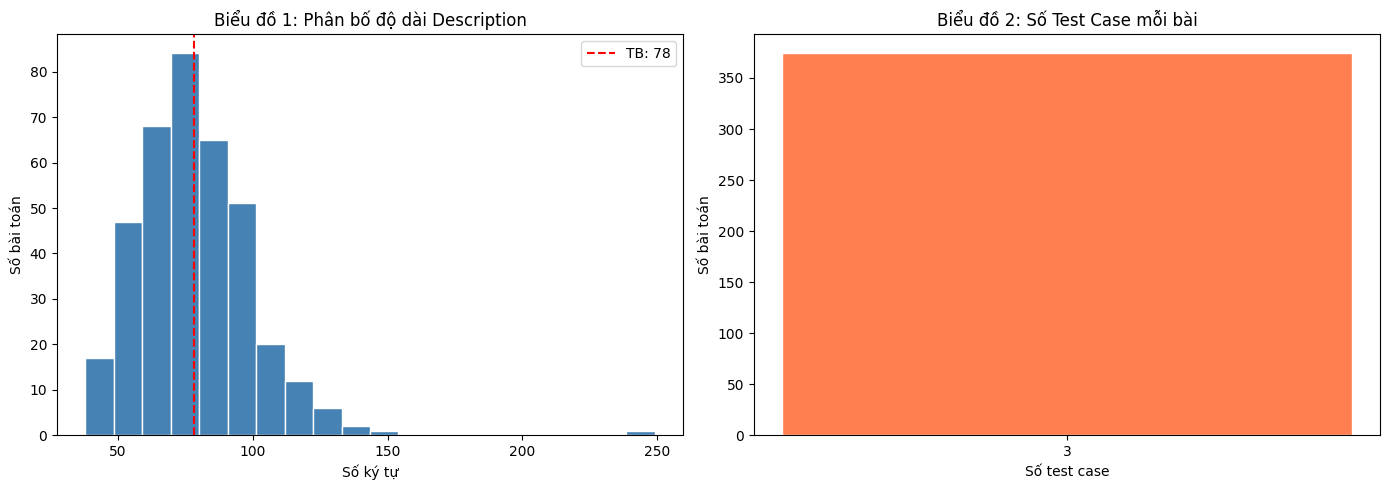

✅ Đã lưu biểu đồ vào results/


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
matplotlib.rcParams["font.family"] = "DejaVu Sans"

cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["desc_length"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Bieu do 1: Phan bo do dai Description")
axes[0].set_xlabel("So ky tu")
axes[0].set_ylabel("So bai toan")
axes[0].axvline(df["desc_length"].mean(), color="red", linestyle="--", label=f"TB: {df['desc_length'].mean():.0f}")
axes[0].legend()

test_counts = df["num_tests"].value_counts().sort_index()
axes[1].bar(test_counts.index.astype(str), test_counts.values, color="coral", edgecolor="white")
axes[1].set_title("Bieu do 2: So Test Case moi bai")
axes[1].set_xlabel("So test case")
axes[1].set_ylabel("So bai toan")

plt.tight_layout()
plt.savefig(BASE / "results" / "data_analysis.png", dpi=150)
plt.show()
print("✅ Da luu bieu do vao results/")

#TẠO TESTCASE VÀ TẠO BIỂU ĐỒ

⏳ Đang chấm điểm so sánh...


/tmp/ipykernel_10559/1629546121.py:121: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x="Chủ đề", y="Pass Rate (%)", hue="Tập Test Case", data=df_results, palette=["#3498db", "#e74c3c"])


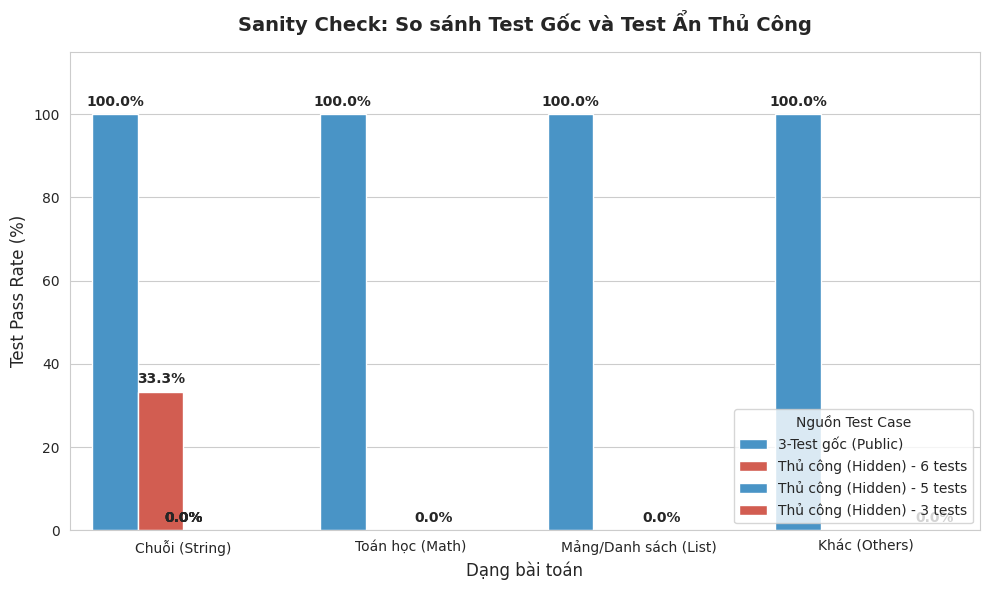

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', category=SyntaxWarning)

# Resolve project root from notebooks/ or workspace root
cwd = Path.cwd().resolve()
BASE = cwd.parent if (cwd / "data").exists() is False and (cwd.parent / "data").exists() else cwd

clean_path = BASE / "data" / "processed" / "mbpp_train_clean.json"
raw_path = BASE / "data" / "raw" / "mbpp_train.json"

if clean_path.exists():
    df = pd.read_json(clean_path)
elif raw_path.exists():
    df = pd.read_json(raw_path)
else:
    df = None
    print("❌ Khong tim thay file du lieu. Hay chay cell tai dataset hoac dat file vao data/processed.")

if df is not None:
    # Infer category from text/code when dataset does not include it
    def infer_category(text, code):
        blob = f"{text} {code}".lower()
        if any(k in blob for k in ["string", "substring", "char", "palindrome", "replace"]):
            return "String"
        if any(k in blob for k in ["list", "array", "sort", "index", "slice"]):
            return "List"
        if any(k in blob for k in ["dict", "dictionary", "set", "key", "value"]):
            return "Dict/Set"
        if any(k in blob for k in ["math", "prime", "factor", "gcd", "lcm", "sum"]):
            return "Math"
        return "Other"

    if "category" not in df.columns:
        df["category"] = df.apply(lambda r: infer_category(r["text"], r["code"]), axis=1)

    # Select 3-5 tasks per category for manual testing
    selected_rows = []
    for cat, df_cat in df.sort_values("task_id").groupby("category"):
        n = min(5, len(df_cat))
        if n < 3:
            n = len(df_cat)
        selected_rows.append(df_cat.head(n))
    df_selected = pd.concat(selected_rows, ignore_index=True)

    # Manual test cases per task_id (fill in)
    MANUAL_TESTS_DICT = {
        # 123: {
        #     "Category": "String",
        #     "manual_tests": ["assert func('abc') == 'a'"]
        # }
    }

    if not MANUAL_TESTS_DICT:
        print("⚠️ Ban chua nhap test thu cong. Hay them test vao MANUAL_TESTS_DICT theo task_id can so sanh.")

    def run_sandbox(code, test_list):
        if not test_list:
            return 0.0
        passed = 0
        safe_code = code.replace('\\', '\\\\')

        import re, math, collections, itertools
        for test in test_list:
            try:
                scope = {
                    "re": re, "math": math,
                    "collections": collections, "itertools": itertools
                }
                exec(safe_code, scope)
                exec(test.replace('\\', '\\\\'), scope)
                passed += 1
            except Exception:
                pass
        return (passed / len(test_list)) * 100

    # Compare pass rates between public tests and manual tests
    results = []
    missing_manual = []
    for _, row in df_selected.iterrows():
        t_id = row["task_id"]
        if t_id not in MANUAL_TESTS_DICT:
            missing_manual.append(t_id)
            continue
        code = row["code"]
        category = MANUAL_TESTS_DICT[t_id].get("Category", row["category"])

        pub_rate = run_sandbox(code, row["test_list"])
        hid_rate = run_sandbox(code, MANUAL_TESTS_DICT[t_id]["manual_tests"])

        results.append({"Chu de": category, "Tap Test Case": "3-Test goc (Public)", "Pass Rate (%)": pub_rate})
        results.append({
            "Chu de": category,
            "Tap Test Case": f"Thu cong (Hidden) - {len(MANUAL_TESTS_DICT[t_id]['manual_tests'])} tests",
            "Pass Rate (%)": hid_rate
        })

    if missing_manual:
        print(f"⚠️ Thieu test thu cong cho {len(missing_manual)} task_id: {missing_manual}")

    if results:
        df_results = pd.DataFrame(results)
        plt.figure(figsize=(11, 6))
        sns.set_style("whitegrid")
        ax = sns.barplot(x="Chu de", y="Pass Rate (%)", hue="Tap Test Case", data=df_results, palette=["#3498db", "#e74c3c"])
        plt.title("So sanh Test Goc va Test Thu Cong", fontsize=14, fontweight='bold', pad=15)
        plt.ylim(0, 115)
        plt.ylabel("Test Pass Rate (%)", fontsize=12)
        plt.xlabel("Dang bai toan", fontsize=12)
        for p in ax.patches:
            h = p.get_height()
            if h >= 0:
                ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontweight='bold', xytext=(0, 4), textcoords='offset points')
        plt.legend(loc='lower right', title="Nguon Test Case")
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Khong co ket qua de ve bieu do. Hay nhap MANUAL_TESTS_DICT.")